In [1]:
%pip install --no-cache-dir -q pywavelets

Note: you may need to restart the kernel to use updated packages.


In [16]:
import torch

from learnable_wavelets import (
    WaveletTransformParameters,
    plots as lw_plots,
    mse_loss,
)

import pywt
import matplotlib.pyplot as plt
import math
import numpy as np

In [3]:
PADDING_MODE = "reflect"
WAVELET_NAME = "db2"

In [4]:
wavelet = pywt.Wavelet(WAVELET_NAME)
filters = torch.stack(
    [
        torch.tensor(wavelet.rec_lo, dtype=torch.float64),
        torch.tensor(wavelet.rec_hi, dtype=torch.float64),
    ]
).unsqueeze(1)

In [5]:
model = WaveletTransformParameters(filters.shape[2]).to(dtype=torch.float64)
compiled_model = torch.compile(model, mode="max-autotune")

In [9]:
def train(model, filters, criteria=1e-19, max_epochs=1_000_000, lr=0.001):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    prev_loss = None
    for _ in range(max_epochs):
        generated_filters = compiled_model()
        loss = mse_loss(generated_filters, filters)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if prev_loss is not None and abs(prev_loss - loss.item()) < criteria:
            break

        prev_loss = loss.item()

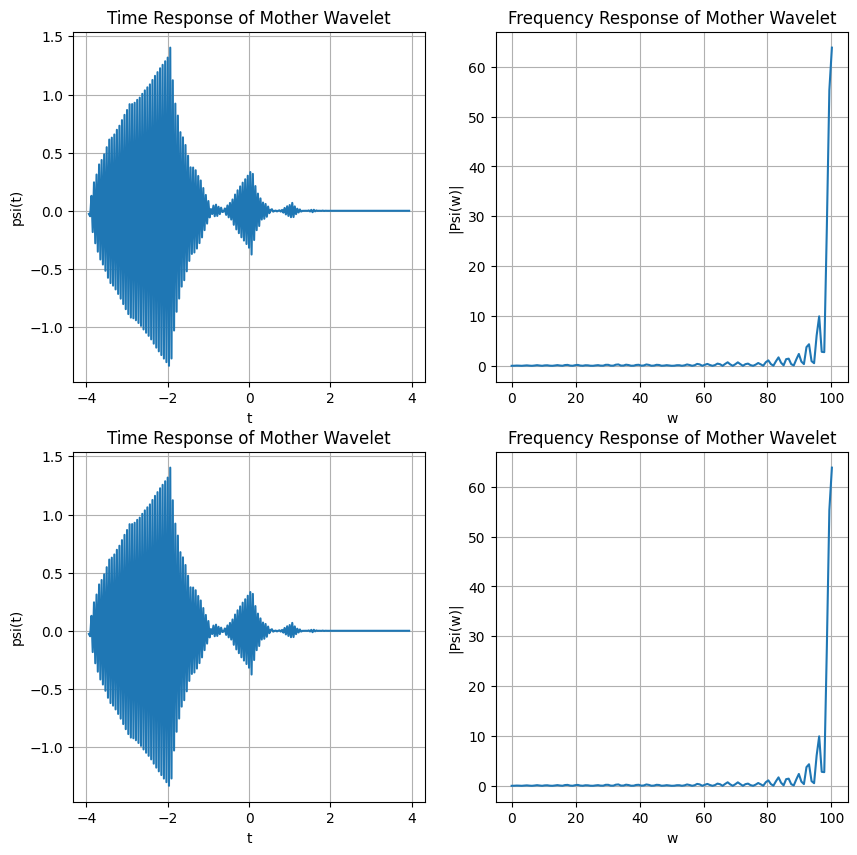

In [10]:
train(compiled_model, filters)

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

lw_plots.plot_wavelet(compiled_model().detach(), (axs[0, 0], axs[0, 1]))
lw_plots.plot_wavelet(filters, (axs[1, 0], axs[1, 1]))

In [11]:
print("Learned angles:")
angles = next(compiled_model.parameters()).detach().numpy()
for i, theta in enumerate(angles):
    print(f"theta_{i}: {theta:.6f} radians, {math.degrees(theta):.2f} degrees")

Learned angles:
theta_0: 1.832596 radians, 105.00 degrees
theta_1: -1.047198 radians, -60.00 degrees


In [12]:
def try_angles(model, angles):
    model.eval()

    with torch.no_grad():
        for param in model.parameters():
            param.copy_(torch.tensor(angles, dtype=torch.float64))

    return mse_loss(model(), filters).item()

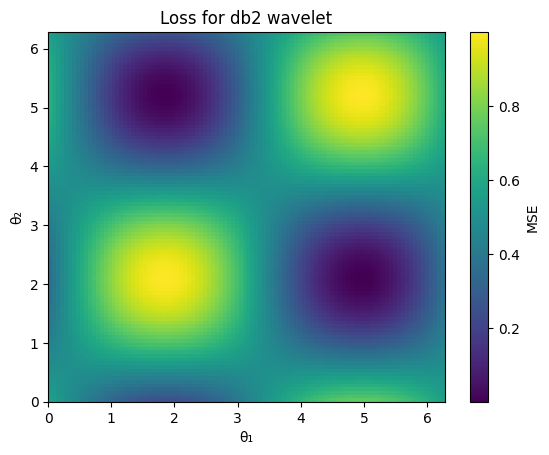

In [ ]:
@np.vectorize
def f(x, y):
    return try_angles(compiled_model, [x, y])


resolution = 100
x = np.linspace(0, 2 * np.pi, resolution)
y = np.linspace(0, 2 * np.pi, resolution)
X, Y = np.meshgrid(x, y)

Z = f(X, Y)

plt.figure()
plt.imshow(Z, extent=(0, 360, 0, 360), origin="lower", aspect="auto")
plt.colorbar(label="MSE")
plt.xlabel("θ₁")
plt.ylabel("θ₂")
plt.title(f"Loss for {WAVELET_NAME} wavelet")
plt.show()